# 03 - Double/Debiased Machine Learning (DDML)

PLR model (Chernozhukov et al., 2018) applied to the Moretti et al. replication.
Main analysis: DML-Lasso + DML-RF. Appendix: EconML cross-checks and CausalForestDML.

## Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('__file__').resolve().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

from src.panel import build_sample, add_country_trends, weighted_demean_twoway

print("numpy", np.__version__)
print("pandas", pd.__version__)

numpy 2.4.3
pandas 3.0.2


## 1. Load panel and construct sample

In [2]:
panel = pd.read_csv('../data/processed/panel.csv')

# col2 sample (all controls non-null) — mirrors OLS Col 3/4
panel = build_sample(panel)
df = panel[panel['col2']].copy().reset_index(drop=True)

print(f"col2 sample: {len(df):,} obs  |  {df['indctry'].nunique()} industry-country cells")
print(f"Countries: {df['ctrynr'].nunique()}  |  Years: {df['year'].nunique()}")


col2 sample: 11,611 obs  |  516 industry-country cells
Countries: 24  |  Years: 22


## 2. Feature engineering and two-way FE absorption

Absorb FEs via FWL (same as notebook 02), then build polynomial features for tree learners.

In [ ]:
# country x yeartrend interactions
df, trend_cols = add_country_trends(df)
print(f"{len(trend_cols)} country-trend interaction columns added")

# control variables
BASE_CONTROLS = ['l1_indctryprod', 'l1_gdp', 'l1_taxsubs'] + trend_cols
Y_COL, D_COL, W_COL = 'lnrdexgov', 'l1_rdgov', 'weight'

# absorb two-way FE via alternating weighted projections
print("Absorbing two-way FEs (indctry + indyear) via Gauss-Seidel...")
w = df[W_COL].values.astype(float)
fe1, fe2 = df['indctry'].values, df['indyear'].values

cols_to_demean = [Y_COL, D_COL] + BASE_CONTROLS
mat = df[cols_to_demean].values.astype(float)
mat_dem = weighted_demean_twoway(mat, fe1, fe2, w)

dem_df = pd.DataFrame(mat_dem, columns=cols_to_demean)
Y_dem = dem_df[Y_COL].values
D_dem = dem_df[D_COL].values
X_dem = dem_df[BASE_CONTROLS].values      # demeaned controls

cl1 = df['indctry'].values
cl2 = df['ctryyear'].values
print(f"Demeaned arrays: Y {Y_dem.shape}, D {D_dem.shape}, X {X_dem.shape}")

23 country-trend interaction columns added
Absorbing two-way FEs (indctry + indyear) via Gauss-Seidel...
Demeaned arrays: Y (11611,), D (11611,), X (11611, 26)


In [4]:
# polynomial feature expansion for the ML learners
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(dem_df[['l1_indctryprod', 'l1_gdp', 'l1_taxsubs']].values)

# combine polynomial expansions + country trends
X_ml = np.hstack([X_poly, dem_df[trend_cols].values])
print(f"ML feature matrix X_ml: {X_ml.shape}  (polynomial + trends)")
print(f"Linear X_dem:           {X_dem.shape}")

ML feature matrix X_ml: (11611, 32)  (polynomial + trends)
Linear X_dem:           (11611, 26)


## 3. DoubleML - Partially Linear Regression 

Two specs: DML-Lasso (linear features, tests H1) and DML-RF (polynomial features, tests H2).
Both use K=5 folds, S=10 reps, DML2 procedure.

In [5]:
from doubleml import DoubleMLData, DoubleMLPLR
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# build DoubleMLData: linear spec and nonlinear spec
dml_data_lin = DoubleMLData.from_arrays(x=X_dem, y=Y_dem, d=D_dem)
dml_data_poly = DoubleMLData.from_arrays(x=X_ml, y=Y_dem, d=D_dem)

print(dml_data_lin)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: y
Treatment variable(s): ['d']
Covariates: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26']
Instrument variable(s): None
No. Observations: 11611
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 11611 entries, 0 to 11610
Columns: 28 entries, X1 to d
dtypes: float64(28)
memory usage: 2.5 MB



In [6]:
np.random.seed(42)

# Spec 1: Lasso nuisance, linear features
dml_lasso = DoubleMLPLR(
    dml_data_lin,
    ml_l=LassoCV(cv=5),
    ml_m=LassoCV(cv=5),
    n_folds=5,
    n_rep=10,
    score='partialling out',
)
dml_lasso.fit()
print(f"DoubleML-Lasso: tau = {dml_lasso.coef[0]:.4f}")

DoubleML-Lasso: tau = 0.1333


In [7]:
np.random.seed(42)

# Spec 2: Random Forest nuisance, polynomial features
dml_rf = DoubleMLPLR(
    dml_data_poly,
    ml_l=RandomForestRegressor(
        n_estimators=200, max_features='sqrt', min_samples_leaf=5, random_state=42
    ),
    ml_m=RandomForestRegressor(
        n_estimators=200, max_features='sqrt', min_samples_leaf=5, random_state=42
    ),
    n_folds=5,
    n_rep=10,
    score='partialling out',
)
dml_rf.fit()
print(f"DoubleML-RF: tau = {dml_rf.coef[0]:.4f}")

DoubleML-RF: tau = 0.0932


In [8]:
dml_results = {}
for name, est in [('DML-Lasso', dml_lasso), ('DML-RF', dml_rf)]:
    dml_results[name] = {'tau': float(est.coef[0])}
    print(f"{name}: tau = {dml_results[name]['tau']:.4f}")

DML-Lasso: tau = 0.1333
DML-RF: tau = 0.0932


### CausalForestDML - heterogeneous treatment effects (Appendix A)

Allows tau(X) to vary with industry output and GDP. GBM nuisance, causal forest second stage.

In [9]:
from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor

# Heterogeneity features: industry output + GDP (captures size/wealth variation)
X_het = dem_df[['l1_indctryprod', 'l1_gdp']].values

np.random.seed(42)
cf_dml = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    n_estimators=500,
    cv=5,
    random_state=42,
)
cf_dml.fit(Y=Y_dem, T=D_dem, X=X_het, W=X_dem,
           sample_weight=w / w.mean())

ate = float(cf_dml.ate(X=X_het))
tau_hat = cf_dml.effect(X=X_het)

print(f"CausalForestDML  ATE = {ate:.4f}")
print(f"CATE range: [{tau_hat.min():.4f}, {tau_hat.max():.4f}]  "
      f"IQR: [{np.percentile(tau_hat,25):.4f}, {np.percentile(tau_hat,75):.4f}]")

CausalForestDML  ATE = 0.1194
CATE range: [-0.5254, 0.6325]  IQR: [0.0503, 0.1849]


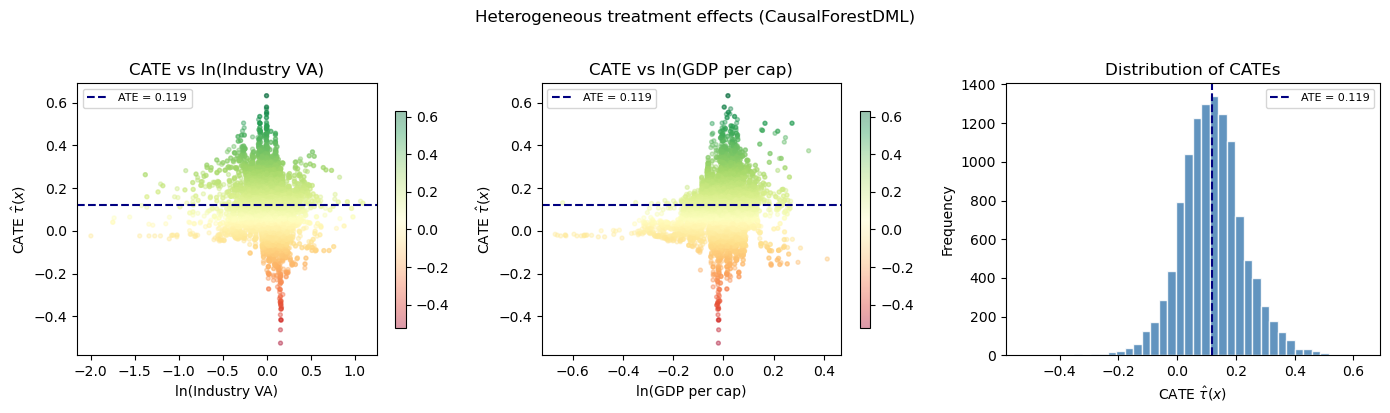

In [10]:
from pathlib import Path
Path('../output').mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_labels = ['ln(Industry VA)', 'ln(GDP per cap)']

for ax, (xi, label) in zip(axes[:2], zip(X_het.T, x_labels)):
    sc = ax.scatter(xi, tau_hat, c=tau_hat, cmap='RdYlGn', alpha=0.4, s=8)
    ax.axhline(ate, color='navy', lw=1.5, ls='--', label=f'ATE = {ate:.3f}')
    ax.set_xlabel(label)
    ax.set_ylabel('CATE $\\hat{\\tau}(x)$')
    ax.set_title(f'CATE vs {label}')
    ax.legend(fontsize=8)
    plt.colorbar(sc, ax=ax, shrink=0.8)

axes[2].hist(tau_hat, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].axvline(ate, color='navy', lw=1.5, ls='--', label=f'ATE = {ate:.3f}')
axes[2].set_xlabel('CATE $\\hat{\\tau}(x)$')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of CATEs')
axes[2].legend(fontsize=8)

fig.suptitle('Heterogeneous treatment effects (CausalForestDML)', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig('../output/fig_hte_causal_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Main comparison table (OLS + DML-Lasso + DML-RF)

In [11]:
# Main-text results (3 estimators)
main_rows = []
main_rows.append({'Method': 'OLS Col 4 (paper)',      'Framework': 'Paper',       'tau': 0.144})
main_rows.append({'Method': 'OLS Col 4 (replicated)', 'Framework': 'run_wls_fe',  'tau': 0.142})

for name, r in dml_results.items():
    main_rows.append({'Method': name, 'Framework': 'DoubleML', 'tau': r['tau']})

main_tbl = pd.DataFrame(main_rows)
main_tbl['diff_from_ols'] = (main_tbl['tau'] - 0.144).round(4)
print("=== MAIN TEXT (Table 1) ===")
print(main_tbl.to_string(index=False))

=== MAIN TEXT (Table 1) ===
                Method  Framework    tau  diff_from_ols
     OLS Col 4 (paper)      Paper 0.1440         0.0000
OLS Col 4 (replicated) run_wls_fe 0.1420        -0.0020
             DML-Lasso   DoubleML 0.1333        -0.0107
                DML-RF   DoubleML 0.0932        -0.0508


## 6. Main-text comparison plot (Figure 1)

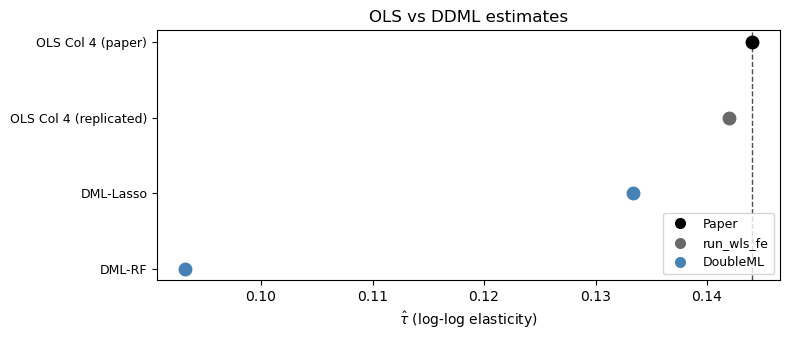

In [12]:
# Figure 1: Main-text comparison (OLS + DML-Lasso + DML-RF)
fig, ax = plt.subplots(figsize=(8, 3.5))

colors = {
    'Paper': 'black',
    'run_wls_fe': 'dimgray',
    'DoubleML': 'steelblue',
}

y_pos = list(range(len(main_rows)))[::-1]
for i, row in enumerate(main_rows):
    yi = y_pos[i]
    col = colors.get(row['Framework'], 'gray')
    ax.plot(row['tau'], yi, 'o', color=col, ms=9, zorder=5)

ax.axvline(0.144, color='black', ls='--', lw=1, alpha=0.7, label='OLS (paper, 0.144)')
ax.set_yticks(y_pos)
ax.set_yticklabels([r['Method'] for r in main_rows], fontsize=9)
ax.set_xlabel(r'$\hat{\tau}$ (log-log elasticity)')
ax.set_title('OLS vs DDML estimates')

from matplotlib.lines import Line2D
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, ms=9, label=f)
              for f, c in colors.items()]
ax.legend(handles=legend_els, fontsize=9, loc='lower right')
fig.tight_layout()
fig.savefig('../output/fig_dml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()